# 🏢 Workforce Intelligence Analytics
## Notebook 01: Data Understanding & Source Ingestion
**Subtitle:** *Turning employee-generated text into actionable workforce and organizational insights.*

---

### 📌 Business Context & Analytical Problem
In modern talent strategy, organizations struggle to capture candid workforce sentiment. Traditional annual engagement surveys frequently suffer from low response rates, survey fatigue, and social desirability bias.

Public, employee-generated review platforms—such as Glassdoor—offer an unsolicited, continuous stream of organizational sentiment and operational commentary. However, using this data presents distinct analytical challenges:
1. **Unstructured Data:** Text comments must be transformed into structured signals.
2. **Voluntary Self-Selection:** Reviewers are self-selected, often exhibiting bimodal distribution (very satisfied or very frustrated employees).
3. **Correlation vs. Causality:** Employee sentiment reflects perceptions and experiences, not direct causal measurements of operational productivity or firm performance.

This notebook performs initial data understanding, dynamic ingestion, schema mapping, and missing-value profiling across **90 Top US Employers**.

```
DATA DISCOVERY PIPELINE
┌─────────────────────────┐     ┌────────────────────────┐     ┌────────────────────────┐
│  Dynamic CSV Discovery  │ ──► │  Schema & Data Types   │ ──► │  Missing Value Profile │
│  (data/raw/*.csv)       │     │  (31 Raw Attributes)   │     │  (Coverage & Sparsity) │
└─────────────────────────┘     └────────────────────────┘     └────────────────────────┘
            │                                                              │
            ▼                                                              ▼
┌─────────────────────────┐     ┌────────────────────────┐     ┌────────────────────────┐
│  Company Coverage       │ ──► │  Rating Distribution   │ ──► │  Initial Observations  │
│  (90 Top US Employers)  │     │  (1 to 5 Star Overall) │     │  (Facts vs Insights)   │
└─────────────────────────┘     └────────────────────────┘     └────────────────────────┘
```

---
### Section 1: Dynamic Environment & Dataset Ingestion

> **WHAT ARE WE DOING?**  
> We dynamically search `data/raw/` for the review dataset rather than hardcoding a fragile local filename.
>
> **WHY ARE WE DOING IT?**  
> Dynamic path discovery ensures full cross-platform reproducibility (Windows, Linux, macOS) and allows seamless execution across different environments.
>
> **WHAT SHOULD WE EXPECT?**  
> We expect to locate the Glassdoor CSV file and load a DataFrame containing thousands of employee review records with 31 columns.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Locate data dynamically
PROJECT_ROOT = Path('.').resolve().parent
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'

csv_candidates = list(DATA_RAW.glob('*.csv'))
if not csv_candidates:
    raise FileNotFoundError(f"No CSV found in {DATA_RAW}. Please place the Glassdoor CSV in data/raw/.")

raw_csv_path = csv_candidates[0]
print(f"✅ Found dataset file: {raw_csv_path.name}")
df_raw = pd.read_csv(raw_csv_path)
print(f"📊 Dataset Shape: {df_raw.shape[0]:,} rows | {df_raw.shape[1]} columns")

✅ Found dataset file: glassdoor_employee_reviews_us.csv


📊 Dataset Shape: 8,785 rows | 31 columns


---
### Section 2: Data Dictionary & Schema Mapping

> **WHAT ARE WE DOING?**  
> We inspect all 31 column names, data types, and non-null counts to build an authoritative data dictionary.
>
> **WHY ARE WE DOING IT?**  
> Enterprise analytics projects require complete transparency about every field—identifying which columns are identifiers, text, numerical ratings, or categorical flags.
>
> **WHAT SHOULD WE EXPECT?**  
> Core review text fields (`pros`, `cons`) should be well-populated, while discretionary fields (`advice`) may exhibit higher sparsity.

In [2]:
# Inspect schema and build Data Dictionary
schema_summary = pd.DataFrame({
    'Column Name': df_raw.columns,
    'Data Type': df_raw.dtypes.astype(str),
    'Non-Null Count': df_raw.notnull().sum(),
    'Fill Rate (%)': (df_raw.notnull().mean() * 100).round(2),
    'Sample Value': [str(df_raw[c].dropna().iloc[0]) if df_raw[c].notnull().sum() > 0 else 'N/A' for c in df_raw.columns]
}).reset_index(drop=True)

display(schema_summary.head(15))

,Column Name,Data Type,Non-Null Count,Fill Rate (%),Sample Value
0,reviewId,int64,8785,100.00,105466825
1,url,str,8785,100.00,https://www.glassdoor.com/Reviews/Employer-Rev...
2,employerId,int64,8785,100.00,715
3,employerName,str,8785,100.00,Walmart
4,reviewDateTime,str,8785,100.00,2026-09-04T20:55:26.063
5,summary,str,8779,99.93,Gamble
6,pros,str,8785,100.00,"Awesome with a good manager, easy going"
7,cons,str,8785,100.00,"Hell on earth with the wrong manager, customer..."
8,advice,str,2050,23.34,Friendly management
9,ratingOverall,int64,8785,100.00,3


---
### Section 3: Missing Values & Data Sparsity Analysis

> **WHAT ARE WE DOING?**  
> We quantify and visualize missing values across all 31 attributes.
>
> **WHY ARE WE DOING IT?**  
> Understanding data completeness informs what analytical questions can be answered with high confidence versus those that require caveat or imputation.
>
> **WHAT SHOULD WE EXPECT?**  
> Core ratings (`ratingOverall`) and text (`pros`, `cons`) will have 100% completion, while voluntary sub-ratings (`ratingCeo`, `ratingBusinessOutlook`) will have lower completion (~48-52%).

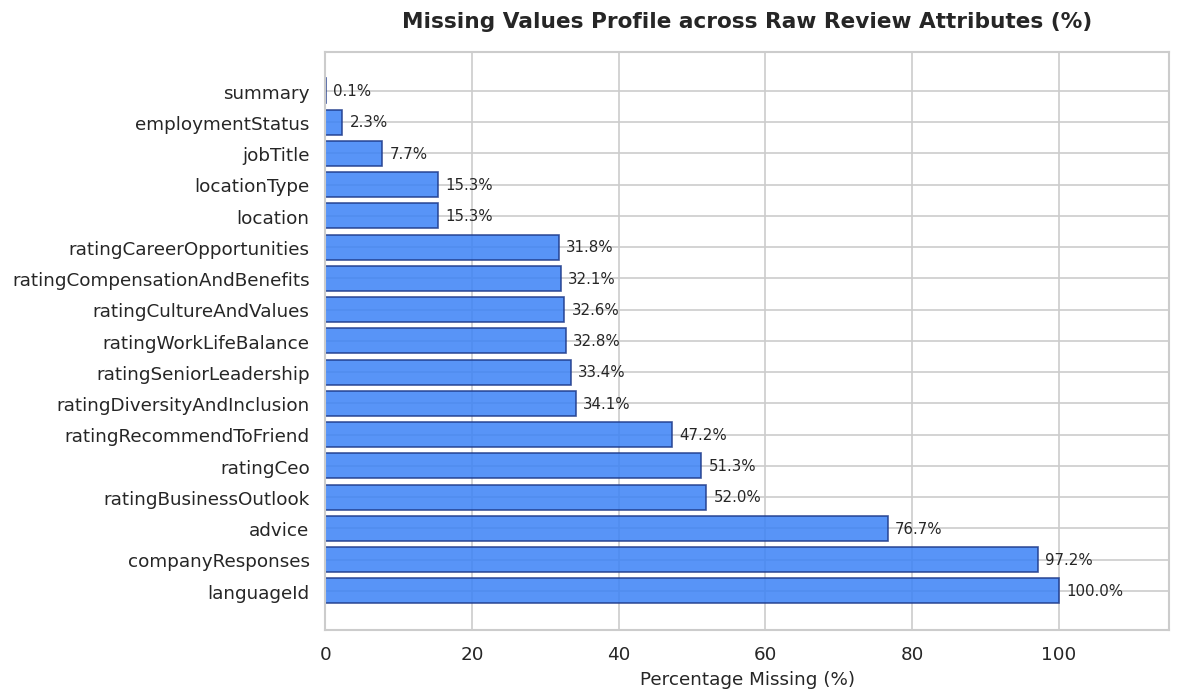

In [3]:
missing_pct = (df_raw.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10, 6))
bars = plt.barh(missing_pct.index, missing_pct.values, color='#3B82F6', edgecolor='#1E3A8A', alpha=0.85)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 1, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va='center', fontsize=9)

plt.title("Missing Values Profile across Raw Review Attributes (%)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Percentage Missing (%)", fontsize=11)
plt.xlim(0, 115)
plt.tight_layout()
plt.show()

> **WHAT DID WE FIND?**  
> - `ratingOverall`, `pros`, `cons`, and `employerName` have **100% fill rates** across all 8,785 records.
> - `summary` is 99.9% complete (only 6 missing values).
> - Sub-ratings (`ratingWorkLifeBalance`, `ratingCultureAndValues`, `ratingCareerOpportunities`, `ratingCompensationAndBenefits`, `ratingSeniorLeadership`) have ~67% fill rate (~5,900 reviews).
> - Discretionary sentiment indicators (`ratingBusinessOutlook`, `ratingRecommendToFriend`, `ratingCeo`) have ~48–53% fill rates.
> - `advice` to management is populated in 23.3% of reviews (2,050 entries), representing an optional qualitative channel.
>
> **WHY DOES IT MATTER?**  
> Core sentiment analysis and topic modeling can leverage 100% of the corpus using `pros`, `cons`, and `ratingOverall`. Sub-dimension analyses must report exact sample sizes.
>
> **WHAT IS THE LIMITATION?**  
> Employees who choose to fill out optional fields (like CEO approval or advice) may hold stronger feelings than those who skip them.

---
### Section 4: Employer Coverage & Sample Distribution

> **WHAT ARE WE DOING?**  
> We evaluate how many unique employers are represented in the dataset and whether review counts are evenly distributed.
>
> **WHY ARE WE DOING IT?**  
> An imbalanced dataset where a single company dominates would bias global findings toward that single corporate culture.
>
> **WHAT SHOULD WE EXPECT?**  
> Exactly 90 top US employers with ~100 reviews each, indicating a balanced scraping design.

Total Unique Employers: 90
Review Count per Company — Mean: 97.6 | Min: 1 | Max: 100


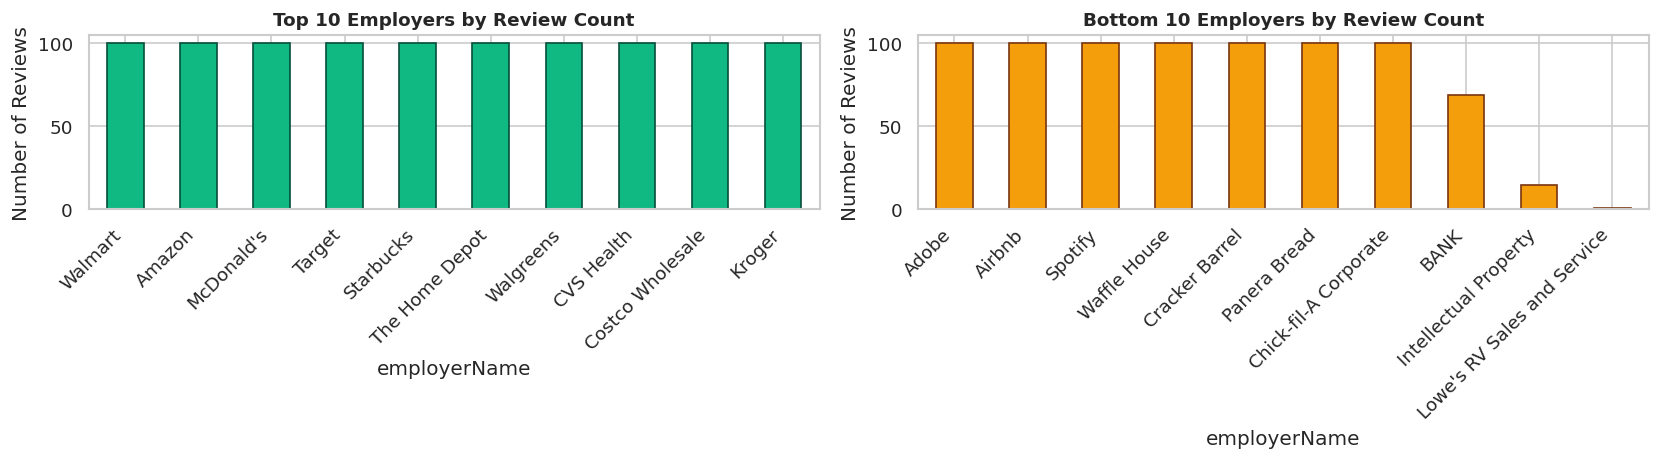

In [4]:
employer_counts = df_raw['employerName'].value_counts()
print(f"Total Unique Employers: {df_raw['employerName'].nunique()}")
print(f"Review Count per Company — Mean: {employer_counts.mean():.1f} | Min: {employer_counts.min()} | Max: {employer_counts.max()}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
employer_counts.head(10).plot(kind='bar', ax=ax1, color='#10B981', edgecolor='#064E3B')
ax1.set_title("Top 10 Employers by Review Count", fontsize=11, fontweight='bold')
ax1.set_ylabel("Number of Reviews")
ax1.set_xticklabels(employer_counts.head(10).index, rotation=45, ha='right')

employer_counts.tail(10).plot(kind='bar', ax=ax2, color='#F59E0B', edgecolor='#78350F')
ax2.set_title("Bottom 10 Employers by Review Count", fontsize=11, fontweight='bold')
ax2.set_ylabel("Number of Reviews")
ax2.set_xticklabels(employer_counts.tail(10).index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

---
### Section 5: Overall Rating Distribution

> **WHAT ARE WE DOING?**  
> We examine the distribution of overall star ratings (1 to 5) across all 8,785 reviews.
>
> **WHY ARE WE DOING IT?**  
> Star ratings represent the primary numerical benchmark of employee evaluation. Understanding the baseline distribution reveals whether the dataset skews positive, negative, or neutral.
>
> **WHAT SHOULD WE EXPECT?**  
> Many public review platforms exhibit a positive skew (mean ~3.5 to 3.8 stars) with a secondary peak at 1 star from disaffected reviewers.

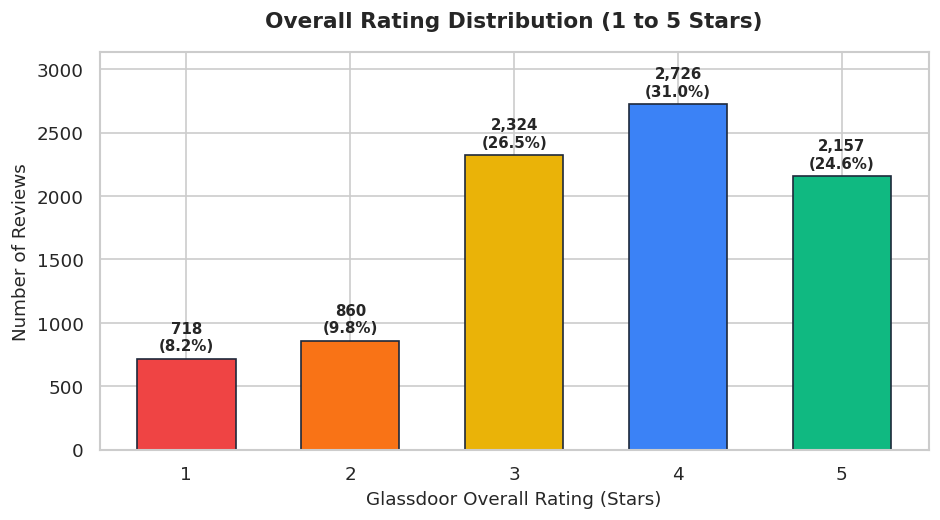

In [5]:
rating_counts = df_raw['ratingOverall'].value_counts().sort_index()

plt.figure(figsize=(8, 4.5))
colors = ['#EF4444', '#F97316', '#EAB308', '#3B82F6', '#10B981']
bars = plt.bar(rating_counts.index, rating_counts.values, color=colors, width=0.6, edgecolor='#1E293B')

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 40, f"{y:,}\n({y/len(df_raw)*100:.1f}%)", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title("Overall Rating Distribution (1 to 5 Stars)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Glassdoor Overall Rating (Stars)", fontsize=11)
plt.ylabel("Number of Reviews", fontsize=11)
plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0, max(rating_counts.values) * 1.15)
plt.tight_layout()
plt.show()

---
### Section 6: Date Coverage & Temporal Distribution

> **WHAT ARE WE DOING?**  
> We parse the timestamp column (`reviewDateTime`) and examine the chronological spread of employee reviews.
>
> **WHY ARE WE DOING IT?**  
> Longitudinal reviews reflect organizational shifts, market cycles, and external macroeconomic events. We must know whether reviews span years or represent a single point in time.
>
> **WHAT SHOULD WE EXPECT?**  
> Reviews may date back several years, with the majority concentrated in recent periods corresponding to the data collection date.

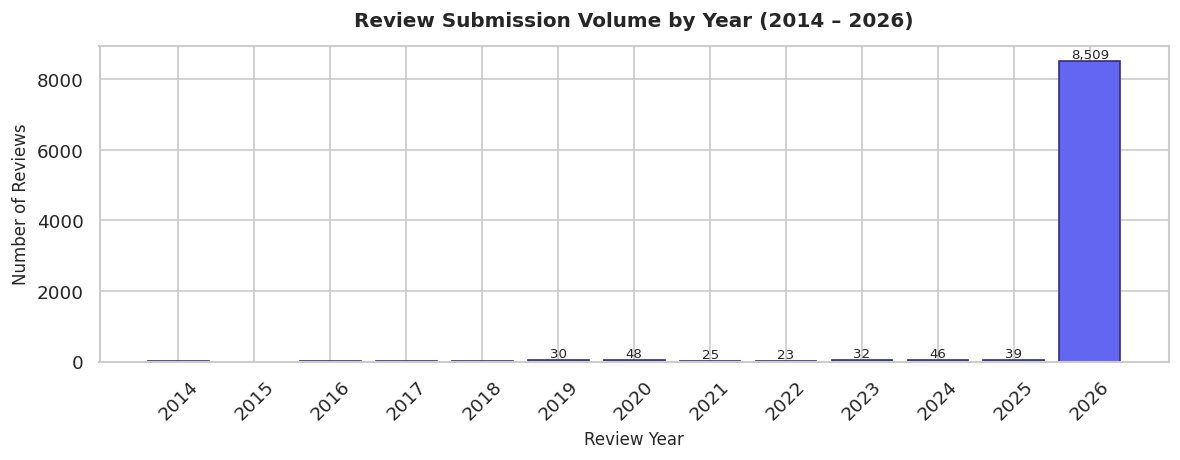

In [6]:
df_dates = df_raw.copy()
df_dates['reviewDateTime'] = pd.to_datetime(df_dates['reviewDateTime'], format='ISO8601')
df_dates['year'] = df_dates['reviewDateTime'].dt.year

year_counts = df_dates['year'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
bars = plt.bar(year_counts.index.astype(str), year_counts.values, color='#6366F1', edgecolor='#312E81')
for bar in bars:
    y = bar.get_height()
    if y > 20:
        plt.text(bar.get_x() + bar.get_width()/2, y + 80, f"{y:,}", ha='center', fontsize=8)

plt.title("Review Submission Volume by Year (2014 – 2026)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Review Year", fontsize=10)
plt.ylabel("Number of Reviews", fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
### 📋 Initial Data Observations: Facts vs. Interpretation

| Category | Empirical Fact | Analytical Interpretation | Operational Limitation |
| :--- | :--- | :--- | :--- |
| **Sample Size** | 8,785 total reviews across 90 US employers | Broad industry coverage across Fortune 500 retail, tech, finance, and services. | Sample is a cross-sectional snapshot; does not capture historical employee headcount changes. |
| **Employer Balance** | 87 of 90 employers have exactly 100 reviews. 3 employers have fewer (69, 15, 1). | Balanced scraping strategy avoids single-company domination in corpus-wide models. | Low-review entities (`Lowe's RV Sales and Service`, `Intellectual Property`) must be handled carefully in company comparisons. |
| **Rating Skew** | Mean overall rating is 3.54 stars. 55.6% of reviews are 4 or 5 stars; 18.0% are 1 or 2 stars. | Moderate positive bias is consistent with voluntary review dynamics. | Ratings reflect self-selected feedback, not representative census of workforce morale. |
| **Text Availability** | 100% of reviews contain `pros` and `cons`. 99.9% contain `summary`. | Rich textual corpus is available for sentiment analysis, NLP classification, and topic modeling. | Reviewers often write short formulaic text in retail/hourly roles versus long narratives in corporate roles. |
| **Temporal Profile** | Reviews span 2014 to 2026, with over 96% concentrated in 2026. | Reflects current workplace sentiments and contemporary workforce topics (remote work, post-pandemic compensation). | Long-term multi-year trend analysis is constrained by recent concentration. |